# Part 1: Exploratory Data Analysis (EDA)

In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

pd.set_option("display.max_columns", 1000)

In [149]:
df_state = pd.read_csv("data/raw/hhs_state_timeseries.csv")

state
date
critical_staffing_shortage_today_yes
critical_staffing_shortage_today_no
critical_staffing_shortage_today_not_reported
critical_staffing_shortage_anticipated_within_week_yes
critical_staffing_shortage_anticipated_within_week_no
inpatient_beds
inpatient_beds_coverage
inpatient_beds_used
inpatient_beds_used_coverage
inpatient_beds_used_covid
inpatient_beds_used_covid_coverage

Combine critical_staffing_shortage_today_yes, critical_staffing_shortage_today_no
Combine critical_staffing_shortage_anticipated_within_week_yes, critical_staffing_shortage_anticipated_within_week_no
Join hospital dataset for total bedcount

In [150]:
list(df_state.columns)

['state',
 'date',
 'critical_staffing_shortage_today_yes',
 'critical_staffing_shortage_today_no',
 'critical_staffing_shortage_today_not_reported',
 'critical_staffing_shortage_anticipated_within_week_yes',
 'critical_staffing_shortage_anticipated_within_week_no',
 'critical_staffing_shortage_anticipated_within_week_not_reported',
 'hospital_onset_covid',
 'hospital_onset_covid_coverage',
 'inpatient_beds',
 'inpatient_beds_coverage',
 'inpatient_beds_used',
 'inpatient_beds_used_coverage',
 'inpatient_beds_used_covid',
 'inpatient_beds_used_covid_coverage',
 'previous_day_admission_adult_covid_confirmed',
 'previous_day_admission_adult_covid_confirmed_coverage',
 'previous_day_admission_adult_covid_suspected',
 'previous_day_admission_adult_covid_suspected_coverage',
 'previous_day_admission_pediatric_covid_confirmed',
 'previous_day_admission_pediatric_covid_confirmed_coverage',
 'previous_day_admission_pediatric_covid_suspected',
 'previous_day_admission_pediatric_covid_suspected_

## Preprocessing¶

In [151]:
to_delete = [
 'staffed_adult_icu_bed_occupancy',
 'staffed_adult_icu_bed_occupancy_coverage',
 'staffed_icu_adult_patients_confirmed_and_suspected_covid',
 'staffed_icu_adult_patients_confirmed_and_suspected_covid_coverage',
 'staffed_icu_adult_patients_confirmed_covid',
 'staffed_icu_adult_patients_confirmed_covid_coverage',
 'total_adult_patients_hospitalized_confirmed_and_suspected_covid',
 'total_adult_patients_hospitalized_confirmed_and_suspected_covid_coverage',
 'total_adult_patients_hospitalized_confirmed_covid',
 'total_adult_patients_hospitalized_confirmed_covid_coverage',
 'total_pediatric_patients_hospitalized_confirmed_and_suspected_covid',
 'total_pediatric_patients_hospitalized_confirmed_and_suspected_covid_coverage',
 'total_pediatric_patients_hospitalized_confirmed_covid',
 'total_pediatric_patients_hospitalized_confirmed_covid_coverage',
 'total_staffed_adult_icu_beds',
 'total_staffed_adult_icu_beds_coverage',
 'adult_icu_bed_covid_utilization',
 'adult_icu_bed_covid_utilization_coverage',
 'adult_icu_bed_covid_utilization_numerator',
 'adult_icu_bed_covid_utilization_denominator',
 'adult_icu_bed_utilization',
 'adult_icu_bed_utilization_coverage',
 'adult_icu_bed_utilization_numerator',
 'adult_icu_bed_utilization_denominator',
 'geocoded_state',
 'all_pediatric_inpatient_bed_occupied',
 'all_pediatric_inpatient_bed_occupied_coverage',
 'all_pediatric_inpatient_beds',
 'all_pediatric_inpatient_beds_coverage',
 'staffed_icu_pediatric_patients_confirmed_covid',
 'staffed_icu_pediatric_patients_confirmed_covid_coverage',
 'staffed_pediatric_icu_bed_occupancy',
 'staffed_pediatric_icu_bed_occupancy_coverage',
 'total_staffed_pediatric_icu_beds',
 'total_staffed_pediatric_icu_beds_coverage']

In [152]:
df_state = df_state.drop(columns= to_delete)

In [153]:
df_state.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81713 entries, 0 to 81712
Data columns (total 100 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   state                                                               81713 non-null  object 
 1   date                                                                81713 non-null  object 
 2   critical_staffing_shortage_today_yes                                81713 non-null  int64  
 3   critical_staffing_shortage_today_no                                 81713 non-null  int64  
 4   critical_staffing_shortage_today_not_reported                       81713 non-null  int64  
 5   critical_staffing_shortage_anticipated_within_week_yes              81713 non-null  int64  
 6   critical_staffing_shortage_anticipated_within_week_no               81713 non-null  int64  
 7   critical_sta

In [154]:
#Explains the same information as the percentage thats caculated with these numerators and denominators.
df_state = df_state.drop(columns = ["inpatient_beds_utilization_coverage", 
                        "inpatient_beds_utilization",
                        "percent_of_inpatients_with_covid",
                        "percent_of_inpatients_with_covid_coverage",
                        "inpatient_bed_covid_utilization",
                        "inpatient_bed_covid_utilization_coverage",
                         ])

In [155]:
df_state.columns

Index(['state', 'date', 'critical_staffing_shortage_today_yes',
       'critical_staffing_shortage_today_no',
       'critical_staffing_shortage_today_not_reported',
       'critical_staffing_shortage_anticipated_within_week_yes',
       'critical_staffing_shortage_anticipated_within_week_no',
       'critical_staffing_shortage_anticipated_within_week_not_reported',
       'hospital_onset_covid', 'hospital_onset_covid_coverage',
       'inpatient_beds', 'inpatient_beds_coverage', 'inpatient_beds_used',
       'inpatient_beds_used_coverage', 'inpatient_beds_used_covid',
       'inpatient_beds_used_covid_coverage',
       'previous_day_admission_adult_covid_confirmed',
       'previous_day_admission_adult_covid_confirmed_coverage',
       'previous_day_admission_adult_covid_suspected',
       'previous_day_admission_adult_covid_suspected_coverage',
       'previous_day_admission_pediatric_covid_confirmed',
       'previous_day_admission_pediatric_covid_confirmed_coverage',
       'previo

# Feature Engineering¶

In [156]:
# Coverage per state (row wise)
df_state["coverage_per_state"] = df_state["critical_staffing_shortage_today_yes"] + df_state["critical_staffing_shortage_today_no"] + df_state["critical_staffing_shortage_today_not_reported"]

In [157]:
# Normalized deaths per hostpital from covid 
df_state["deaths_covid"] = df_state["deaths_covid"] / (df_state["deaths_covid_coverage"])

# Staffing shortage ratio
df_state["state_staffing_shortage_ratio"] = df_state["critical_staffing_shortage_today_yes"] / (df_state["critical_staffing_shortage_today_yes"] + df_state["critical_staffing_shortage_today_no"])

# Reporting completeness
df_state["state_staffing_reporting_completeness"] = (df_state["critical_staffing_shortage_today_yes"] + df_state["critical_staffing_shortage_today_no"]) / (
    df_state["coverage_per_state"]
)

# Reporting for next week (staffing shortage) ratio
df_state["state_staffing_shortage_anticipation_ratio"] = df_state["critical_staffing_shortage_anticipated_within_week_yes"] / (df_state["critical_staffing_shortage_anticipated_within_week_yes"] + df_state["critical_staffing_shortage_anticipated_within_week_no"])

# Reporting for next week (staffing shortage) completeness
df_state["state_staffing_shortage_anticipation_completeness"] = (df_state["critical_staffing_shortage_anticipated_within_week_yes"] + df_state["critical_staffing_shortage_anticipated_within_week_no"]) / (
    df_state["critical_staffing_shortage_anticipated_within_week_yes"] + df_state["critical_staffing_shortage_anticipated_within_week_no"] + df_state["critical_staffing_shortage_anticipated_within_week_not_reported"] )

In [158]:
df_state = df_state.drop(columns = ["deaths_covid_coverage", "deaths_covid", "critical_staffing_shortage_anticipated_within_week_yes", "critical_staffing_shortage_anticipated_within_week_no",
                         "critical_staffing_shortage_anticipated_within_week_not_reported"])

In [159]:
# Normalized beds total per hospital 
df_state["hospital_inpatient_beds"] = df_state["inpatient_beds"] / (df_state["inpatient_beds_coverage"])

# Normalized beds used per hospital 
df_state["hospital_inpatient_beds_used"] = df_state["inpatient_beds_used"] / (df_state["inpatient_beds_used_coverage"])


#Normalized count for covid plus influenza patients
df_state["total_patients_hospitalized_confirmed_influenza_and_covid"] = df_state["total_patients_hospitalized_confirmed_influenza_and_covid"] / (df_state["total_patients_hospitalized_confirmed_influenza_and_covid_coverage"])


df_state = df_state.drop(columns = ["hospital_onset_covid_coverage", "inpatient_beds_coverage", "inpatient_beds_used_coverage", "inpatient_beds_used_covid_coverage",
"icu_patients_confirmed_influenza_coverage", "total_patients_hospitalized_confirmed_influenza_coverage", "total_patients_hospitalized_confirmed_influenza_and_covid_coverage"])

In [160]:
df_state.columns

Index(['state', 'date', 'critical_staffing_shortage_today_yes',
       'critical_staffing_shortage_today_no',
       'critical_staffing_shortage_today_not_reported', 'hospital_onset_covid',
       'inpatient_beds', 'inpatient_beds_used', 'inpatient_beds_used_covid',
       'previous_day_admission_adult_covid_confirmed',
       'previous_day_admission_adult_covid_confirmed_coverage',
       'previous_day_admission_adult_covid_suspected',
       'previous_day_admission_adult_covid_suspected_coverage',
       'previous_day_admission_pediatric_covid_confirmed',
       'previous_day_admission_pediatric_covid_confirmed_coverage',
       'previous_day_admission_pediatric_covid_suspected',
       'previous_day_admission_pediatric_covid_suspected_coverage',
       'inpatient_beds_utilization_numerator',
       'inpatient_beds_utilization_denominator',
       'percent_of_inpatients_with_covid_numerator',
       'percent_of_inpatients_with_covid_denominator',
       'inpatient_bed_covid_utilizati

In [161]:
df_state = df_state.drop(columns = ["inpatient_beds_utilization_numerator",
"inpatient_beds_utilization_denominator",
'percent_of_inpatients_with_covid_numerator',
'percent_of_inpatients_with_covid_denominator',
'inpatient_bed_covid_utilization_numerator',
'inpatient_bed_covid_utilization_denominator', "critical_staffing_shortage_today_yes",
"critical_staffing_shortage_today_no", "critical_staffing_shortage_today_not_reported"]
       )

# Feature Engineering¶

In [162]:
df_state["previous_day_admission_adult_covid_suspected_80"] = df_state["previous_day_admission_adult_covid_suspected_80_"]
df_state = df_state.drop(columns="previous_day_admission_adult_covid_suspected_80_")

In [163]:
def normalize_cols(df:pd.DataFrame):
    df_normalized = df.copy()
    for col in df.columns:
        if "_coverage" in col:
            new_name = col.replace("_coverage", "")
            normalized = df[new_name] / df[col]
            df_normalized[new_name + "_normalized"] = normalized
            df_normalized = df_normalized.drop(columns=[col, new_name])
        elif '_utilization' in col:
            df_normalized.drop(columns=col)
        else:
            continue
    return df_normalized
df_normalized = normalize_cols(df_state)
df_normalized

,state,date,hospital_onset_covid,inpatient_beds,inpatient_beds_used,inpatient_beds_used_covid,on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses,on_hand_supply_therapeutic_b_bamlanivimab_courses,on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses,previous_week_therapeutic_a_casirivimab_imdevimab_courses_used,previous_week_therapeutic_b_bamlanivimab_courses_used,previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used,icu_patients_confirmed_influenza,total_patients_hospitalized_confirmed_influenza,total_patients_hospitalized_confirmed_influenza_and_covid,coverage_per_state,state_staffing_shortage_ratio,state_staffing_reporting_completeness,state_staffing_shortage_anticipation_ratio,state_staffing_shortage_anticipation_completeness,hospital_inpatient_beds,hospital_inpatient_beds_used,previous_day_admission_adult_covid_confirmed_normalized,previous_day_admission_adult_covid_suspected_normalized,previous_day_admission_pediatric_covid_confirmed_normalized,previous_day_admission_pediatric_covid_suspected_normalized,previous_day_admission_adult_covid_confirmed_18_19_normalized,previous_day_admission_adult_covid_confirmed_20_29_normalized,previous_day_admission_adult_covid_confirmed_30_39_normalized,previous_day_admission_adult_covid_confirmed_40_49_normalized,previous_day_admission_adult_covid_confirmed_50_59_normalized,previous_day_admission_adult_covid_confirmed_60_69_normalized,previous_day_admission_adult_covid_confirmed_70_79_normalized,previous_day_admission_adult_covid_confirmed_80_normalized,previous_day_admission_adult_covid_confirmed_unknown_normalized,previous_day_admission_adult_covid_suspected_18_19_normalized,previous_day_admission_adult_covid_suspected_20_29_normalized,previous_day_admission_adult_covid_suspected_30_39_normalized,previous_day_admission_adult_covid_suspected_40_49_normalized,previous_day_admission_adult_covid_suspected_50_59_normalized,previous_day_admission_adult_covid_suspected_60_69_normalized,previous_day_admission_adult_covid_suspected_70_79_normalized,previous_day_admission_adult_covid_suspected_80_normalized,previous_day_admission_adult_covid_suspected_unknown_normalized,previous_day_admission_influenza_confirmed_normalized,previous_day_deaths_covid_and_influenza_normalized,previous_day_deaths_influenza_normalized,previous_day_admission_pediatric_covid_confirmed_0_4_normalized,previous_day_admission_pediatric_covid_confirmed_12_17_normalized,previous_day_admission_pediatric_covid_confirmed_5_11_normalized,previous_day_admission_pediatric_covid_confirmed_unknown_normalized
0,AL,2020-01-01T00:00:00.000,NaN,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,0.000000,NaN,0.000000,6.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HI,2020-01-01T00:00:00.000,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,0.000000,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IN,2020-01-01T00:00:00.000,0.0,30.0,15.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,0.000000,NaN,0.000000,30.000000,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LA,2020-01-01T00:00:00.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MN,2020-01-01T00:00:00.000,0.0,46.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,0.000000,NaN,0.000000,46.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81708,VT,2024-04-2

## Final column drop of highly correlated or irrelevant features

In [164]:
df_normalized.columns

Index(['state', 'date', 'hospital_onset_covid', 'inpatient_beds',
       'inpatient_beds_used', 'inpatient_beds_used_covid',
       'on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses',
       'on_hand_supply_therapeutic_b_bamlanivimab_courses',
       'on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses',
       'previous_week_therapeutic_a_casirivimab_imdevimab_courses_used',
       'previous_week_therapeutic_b_bamlanivimab_courses_used',
       'previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used',
       'icu_patients_confirmed_influenza',
       'total_patients_hospitalized_confirmed_influenza',
       'total_patients_hospitalized_confirmed_influenza_and_covid',
       'coverage_per_state', 'state_staffing_shortage_ratio',
       'state_staffing_reporting_completeness',
       'state_staffing_shortage_anticipation_ratio',
       'state_staffing_shortage_anticipation_completeness',
       'hospital_inpatient_beds', 'hospital_inpatient_beds_used',
     

In [165]:
df_normalized = df_normalized.drop(columns = ["inpatient_beds", "hospital_onset_covid", "inpatient_beds_used", "inpatient_beds_used_covid", "icu_patients_confirmed_influenza", "total_patients_hospitalized_confirmed_influenza",
"total_patients_hospitalized_confirmed_influenza_and_covid", "previous_day_deaths_influenza_normalized"])

# Final List of Columns:

For modeling rate use inpatient_beds_utilization without 'state', 'date', inpatient_beds', 'inpatient_beds_used',
'inpatient_beds_utilization_coverage',hospital_inpatient_beds_used
for modeling continous rv like hospital_inpatient_beds_used, exclude: "state", "date", 'inpatient_beds', 'inpatient_beds_used',
'inpatient_beds_utilization', 'inpatient_beds_utilization_coverage'

In [166]:
final_cols = list(df_normalized.columns)
df_normalized.columns 

Index(['state', 'date',
       'on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses',
       'on_hand_supply_therapeutic_b_bamlanivimab_courses',
       'on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses',
       'previous_week_therapeutic_a_casirivimab_imdevimab_courses_used',
       'previous_week_therapeutic_b_bamlanivimab_courses_used',
       'previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used',
       'coverage_per_state', 'state_staffing_shortage_ratio',
       'state_staffing_reporting_completeness',
       'state_staffing_shortage_anticipation_ratio',
       'state_staffing_shortage_anticipation_completeness',
       'hospital_inpatient_beds', 'hospital_inpatient_beds_used',
       'previous_day_admission_adult_covid_confirmed_normalized',
       'previous_day_admission_adult_covid_suspected_normalized',
       'previous_day_admission_pediatric_covid_confirmed_normalized',
       'previous_day_admission_pediatric_covid_suspected_normalized',
   

## Create Lagged Features

In [167]:
df_sorted = df_normalized.sort_values(["state", "date"]).copy()


In [168]:
df_sorted["beds_used_lag1"] = df_sorted.groupby("state")["hospital_inpatient_beds_used"].shift(7)
df_sorted["beds_used_lag2"] = df_sorted.groupby("state")["hospital_inpatient_beds_used"].shift(14)
df_sorted["beds_used_rolling4"] = df_sorted.groupby("state")["hospital_inpatient_beds_used"].transform(
    lambda x: x.shift(7).rolling(28).mean()
)

df_sorted["state_staffing_shortage_ratio_lag1"] = df_sorted.groupby("state")["state_staffing_shortage_ratio"].shift(7)
df_sorted["state_staffing_shortage_ratio_lag2"] = df_sorted.groupby("state")["state_staffing_shortage_ratio"].shift(14)
df_sorted["state_staffing_shortage_ratio_rolling4"] = df_sorted.groupby("state")["state_staffing_shortage_ratio"].transform(
    lambda x: x.shift(7).rolling(28).mean()
)

In [169]:
df_sorted = df_sorted.drop(columns = ['previous_day_admission_pediatric_covid_confirmed_normalized',
       'previous_day_admission_adult_covid_confirmed_normalized',
       'previous_day_admission_adult_covid_suspected_normalized',
       ])

## Final Column selection

In [170]:
df_columns_for_modeling = df_sorted.copy()

df_columns_for_modeling.columns

Index(['state', 'date',
       'on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses',
       'on_hand_supply_therapeutic_b_bamlanivimab_courses',
       'on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses',
       'previous_week_therapeutic_a_casirivimab_imdevimab_courses_used',
       'previous_week_therapeutic_b_bamlanivimab_courses_used',
       'previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used',
       'coverage_per_state', 'state_staffing_shortage_ratio',
       'state_staffing_reporting_completeness',
       'state_staffing_shortage_anticipation_ratio',
       'state_staffing_shortage_anticipation_completeness',
       'hospital_inpatient_beds', 'hospital_inpatient_beds_used',
       'previous_day_admission_pediatric_covid_suspected_normalized',
       'previous_day_admission_adult_covid_confirmed_18_19_normalized',
       'previous_day_admission_adult_covid_confirmed_20_29_normalized',
       'previous_day_admission_adult_covid_confirmed_30_39_no

In [171]:
df_columns_for_modeling.to_csv('data/clean/final_featuresv2.csv', index=False)

In [172]:
df_sorted

,state,date,on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses,on_hand_supply_therapeutic_b_bamlanivimab_courses,on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses,previous_week_therapeutic_a_casirivimab_imdevimab_courses_used,previous_week_therapeutic_b_bamlanivimab_courses_used,previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used,coverage_per_state,state_staffing_shortage_ratio,state_staffing_reporting_completeness,state_staffing_shortage_anticipation_ratio,state_staffing_shortage_anticipation_completeness,hospital_inpatient_beds,hospital_inpatient_beds_used,previous_day_admission_pediatric_covid_suspected_normalized,previous_day_admission_adult_covid_confirmed_18_19_normalized,previous_day_admission_adult_covid_confirmed_20_29_normalized,previous_day_admission_adult_covid_confirmed_30_39_normalized,previous_day_admission_adult_covid_confirmed_40_49_normalized,previous_day_admission_adult_covid_confirmed_50_59_normalized,previous_day_admission_adult_covid_confirmed_60_69_normalized,previous_day_admission_adult_covid_confirmed_70_79_normalized,previous_day_admission_adult_covid_confirmed_80_normalized,previous_day_admission_adult_covid_confirmed_unknown_normalized,previous_day_admission_adult_covid_suspected_18_19_normalized,previous_day_admission_adult_covid_suspected_20_29_normalized,previous_day_admission_adult_covid_suspected_30_39_normalized,previous_day_admission_adult_covid_suspected_40_49_normalized,previous_day_admission_adult_covid_suspected_50_59_normalized,previous_day_admission_adult_covid_suspected_60_69_normalized,previous_day_admission_adult_covid_suspected_70_79_normalized,previous_day_admission_adult_covid_suspected_80_normalized,previous_day_admission_adult_covid_suspected_unknown_normalized,previous_day_admission_influenza_confirmed_normalized,previous_day_deaths_covid_and_influenza_normalized,previous_day_admission_pediatric_covid_confirmed_0_4_normalized,previous_day_admission_pediatric_covid_confirmed_12_17_normalized,previous_day_admission_pediatric_covid_confirmed_5_11_normalized,previous_day_admission_pediatric_covid_confirmed_unknown_normalized,beds_used_lag1,beds_used_lag2,beds_used_rolling4,state_staffing_shortage_ratio_lag1,state_staffing_shortage_ratio_lag2,state_staffing_shortage_ratio_rolling4
1434,AK,2020-03-23T00:00:00.000,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,0.0,NaN,0.000000,56.000000,21.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1479,AK,2020-03-24T00:00:00.000,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,0.0,NaN,0.000000,56.000000,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1525,AK,2020-03-25T00:00:00.000,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,0.0,NaN,0.000000,56.000000,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1572,AK,2020-03-26T00:00:00.000,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,0.0,NaN,0.000000,56.000000,16.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1619,AK,2020-03-27T00:00:00.000,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,0.0,NaN,0.000000,40.500000,11.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81496,WY,2024-04-23T00:00:00.000,2.0,NaN,99.0,0.0,NaN,0.0,27,NaN,0.0,0.050000,0.740741,48.074074,21.777778,0.000000,0.0,0.0,0.0,0.0,0.0,0.037037,0.000000,0.037037,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.150000,0.05,0.100000,0.0,0.037037,0.0,0.0,0.0,0.0,0.0,22.208333,22.840000,21.217077,NaN,NaN,NaN
81550,WY,2024-04-24T00:00:00.000,81.0,NaN,115.0,0.0,NaN,0.0,26,NaN,0.0,0.052632,0.730769,48.846

# Part 3: Random Forest Regressor

## 1. Imports

In [173]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score

## 2. Data Loading & Cleaning

In [174]:
df = pd.read_csv('data/clean/final_featuresv2.csv')

exclude_cols = [
    'state', "hospital_inpatient_beds", "coverage_per_state",
    #lots of missing values for pediatric admission attributes
    'previous_day_admission_pediatric_covid_confirmed_12_17_normalized',
    'previous_day_admission_pediatric_covid_confirmed_5_11_normalized',
    'previous_day_admission_pediatric_covid_confirmed_unknown_normalized',
    'previous_day_admission_pediatric_covid_confirmed_0_4_normalized'
]
columns_of_interest = [c for c in df.columns if c not in exclude_cols]

df = df[columns_of_interest].copy()

In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81713 entries, 0 to 81712
Data columns (total 39 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   date                                                              81713 non-null  object 
 1   on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses        63546 non-null  float64
 2   on_hand_supply_therapeutic_b_bamlanivimab_courses                 61432 non-null  float64
 3   on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses      58856 non-null  float64
 4   previous_week_therapeutic_a_casirivimab_imdevimab_courses_used    63585 non-null  float64
 5   previous_week_therapeutic_b_bamlanivimab_courses_used             61505 non-null  float64
 6   previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used  58913 non-null  float64
 7   state_staffing_shortage_ratio  

In [176]:
df = df.dropna()

In [177]:
df.shape

(54419, 39)

## 3. Random Forest — Predicting `inpatient_beds_used`

### Split into train and test data based on the 80 percent quantile of date

In [189]:
SEED = 42

df["date"] = pd.to_datetime(df["date"])
cutoff_date = df["date"].quantile(0.8)

train = df[df["date"] <= cutoff_date]
test = df[df["date"] > cutoff_date]

X_train = train.drop(columns = ["hospital_inpatient_beds_used", "date"])
y_train = train["hospital_inpatient_beds_used"]

X_test = test.drop(columns = ["hospital_inpatient_beds_used", "date"])
y_test = test["hospital_inpatient_beds_used"]


### WITHOUT LAG FEATURES

In [190]:
X_train_wo_lag = train.drop(columns = ["hospital_inpatient_beds_used", "date", "beds_used_lag1", "beds_used_lag2", "beds_used_rolling4"])
X_test_wo_lag = test.drop(columns = ["hospital_inpatient_beds_used", "date", "beds_used_lag1", "beds_used_lag2", "beds_used_rolling4"])

In [191]:
rfr_wolag = RandomForestRegressor(n_estimators= 1000, random_state=SEED, max_features= "sqrt", n_jobs= -1)

rfr_wolag.fit(X_train_wo_lag, y_train)


,n_estimators,1000
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [192]:
r2_train = r2_score(y_train, rfr_wolag.predict(X_train_wo_lag))
r2_test  = r2_score(y_test,  rfr_wolag.predict(X_test_wo_lag))

print(f"Train R²: {r2_train:.4f}")
print(f"Test  R²: {r2_test:.4f}")
print(f"Gap:      {r2_train - r2_test:.4f}  (>0.05 suggests overfitting)")

Train R²: 0.9935
Test  R²: 0.6253
Gap:      0.3682  (>0.05 suggests overfitting)


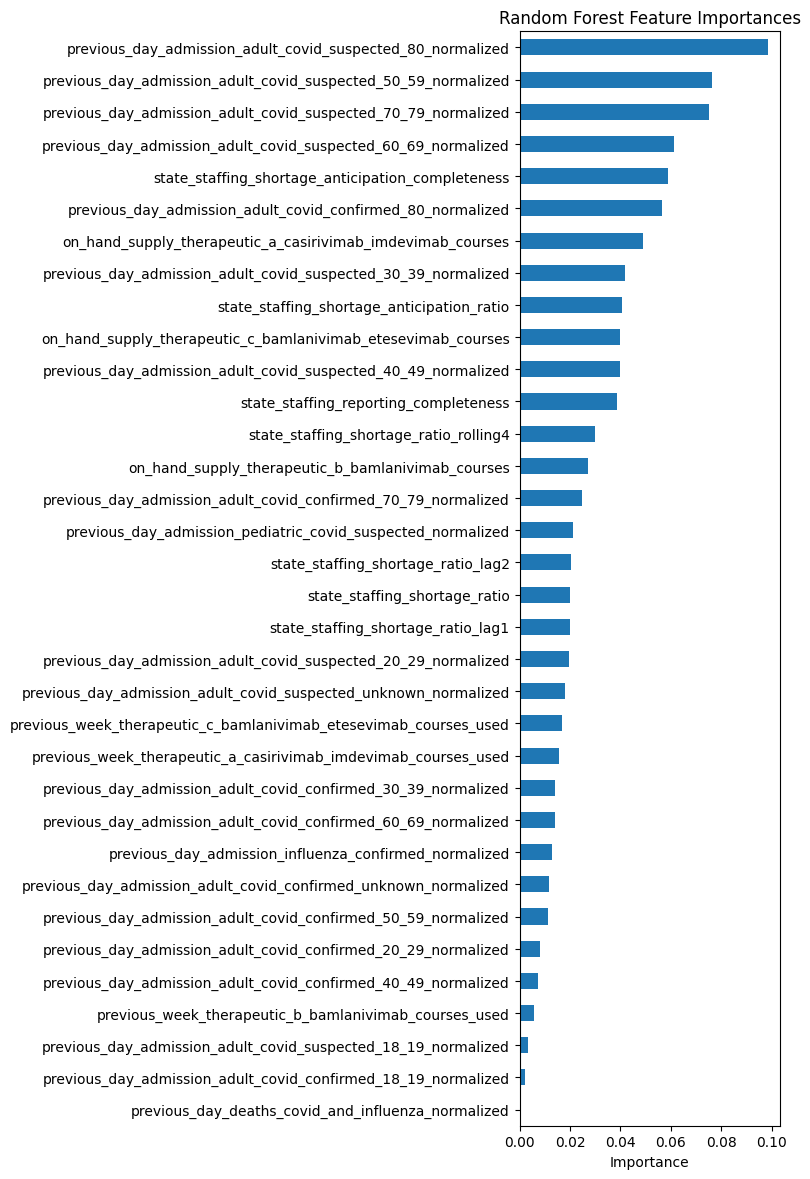

In [193]:
importances = pd.Series(rfr_wolag.feature_importances_, index=X_train_wo_lag.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, len(importances) * 0.35))
importances.plot(kind='barh', ax=ax)
ax.set_title('Random Forest Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

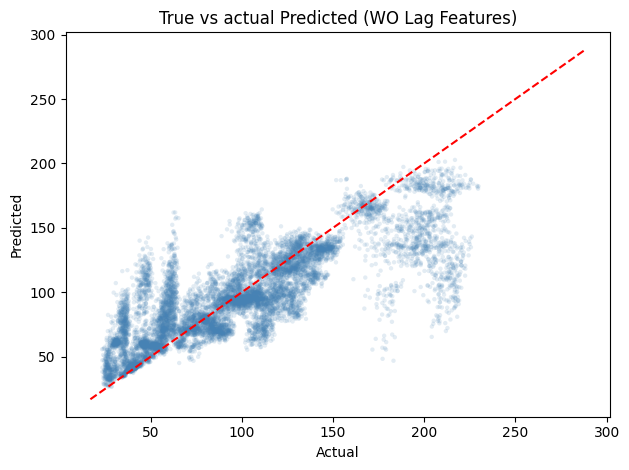

In [194]:
predictions = rfr_wolag.predict(X_test_wo_lag)
plt.scatter(y_test, predictions, alpha=0.15, s=10, color='steelblue', edgecolors='none')

lo = min(y.min(), predictions.min())
hi = max(y.max(), predictions.max())
plt.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5)

plt.title("True vs actual Predicted (WO Lag Features)")
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()

### Analysis demonstrates the importance of lag features for the response variable in order to capture the larger values of per hospital inpatient beds used values.

## RFR With Lag Features

In [195]:
rfr = RandomForestRegressor(n_estimators= 1000, random_state=SEED, max_features= "sqrt", n_jobs= -1)

rfr.fit(X_train, y_train)


,n_estimators,1000
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [197]:
r2_train = r2_score(y_train, rfr.predict(X_train))
r2_test  = r2_score(y_test,  rfr.predict(X_test))

print(f"Train R²: {r2_train:.4f}")
print(f"Test  R²: {r2_test:.4f}")
print(f"Gap:      {r2_train - r2_test:.4f}  (>0.05 suggests overfitting)")

Train R²: 0.9995
Test  R²: 0.9910
Gap:      0.0085  (>0.05 suggests overfitting)


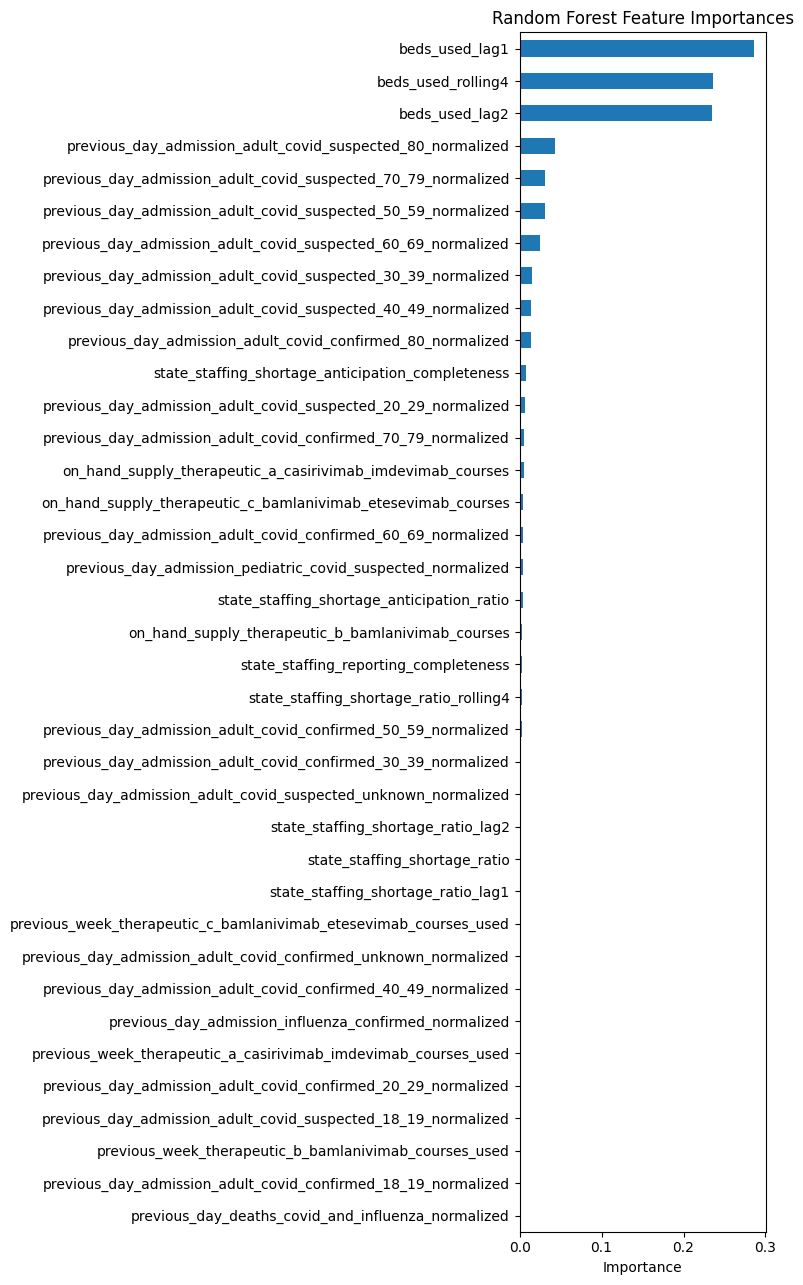

In [199]:
importances = pd.Series(rfr.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, len(importances) * 0.35))
importances.plot(kind='barh', ax=ax)
ax.set_title('Random Forest Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

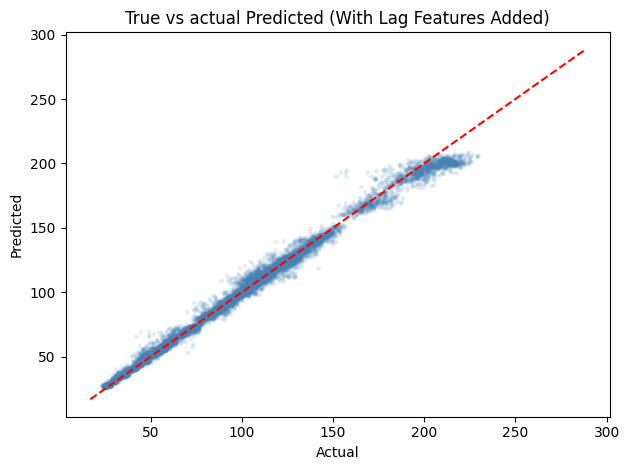

In [201]:
predictions = rfr.predict(X_test)
plt.scatter(y_test, predictions, alpha=0.15, s=10, color='steelblue', edgecolors='none')

lo = min(y.min(), predictions.min())
hi = max(y.max(), predictions.max())
plt.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5)

plt.title("True vs actual Predicted (With Lag Features Added)")
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()

# XGBoost Model

In [202]:
from xgboost import XGBRegressor

XGBr = XGBRegressor(n_estimators=1000, max_depth=5, learning_rate=0.1, subsample = 0.5, colsample_bytree = 0.3)

XGBr.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.3
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [203]:
r2_train = r2_score(y_train, XGBr.predict(X_train))
r2_test  = r2_score(y_test,  XGBr.predict(X_test))

print(f"Train R²: {r2_train:.4f}")
print(f"Test  R²: {r2_test:.4f}")
print(f"Gap:      {r2_train - r2_test:.4f}  (>0.05 suggests overfitting)")

Train R²: 0.9982
Test  R²: 0.9897
Gap:      0.0085  (>0.05 suggests overfitting)


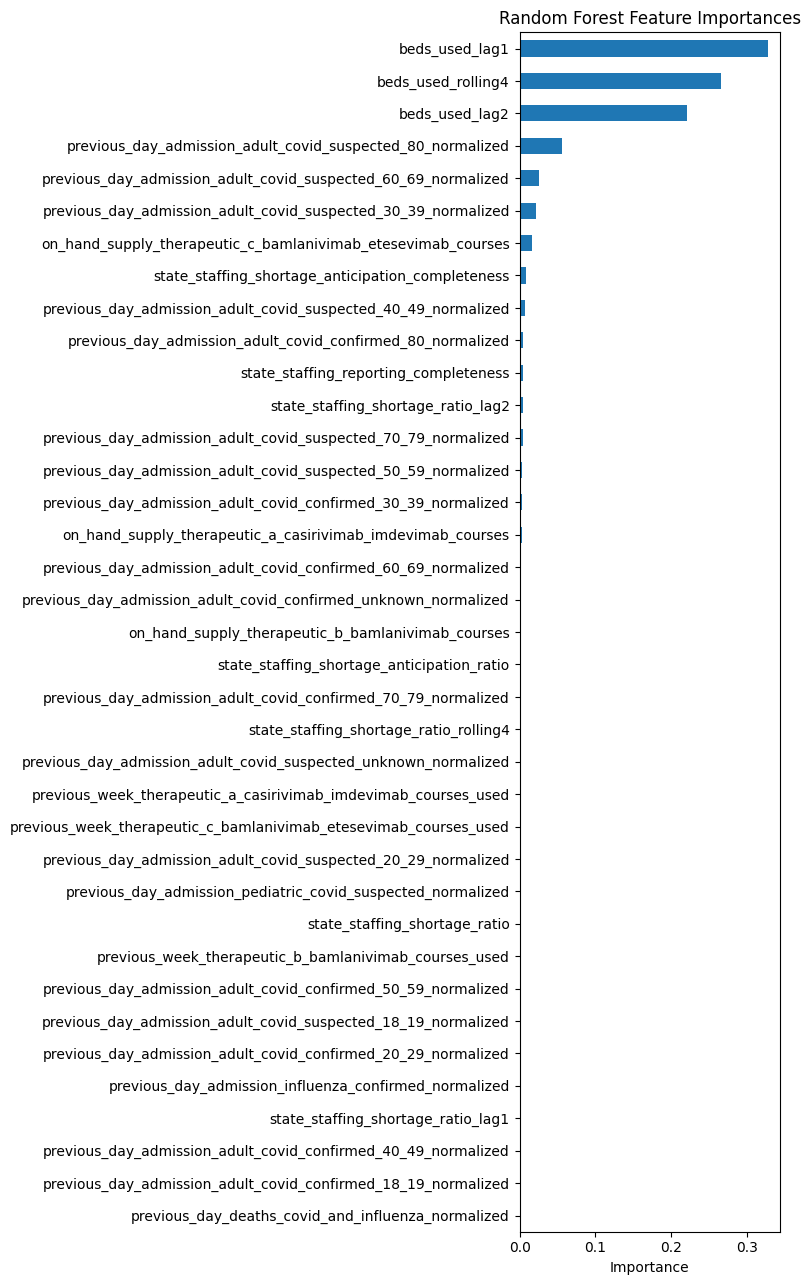

In [204]:
importances = pd.Series(XGBr.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, len(importances) * 0.35))
importances.plot(kind='barh', ax=ax)
ax.set_title('Random Forest Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

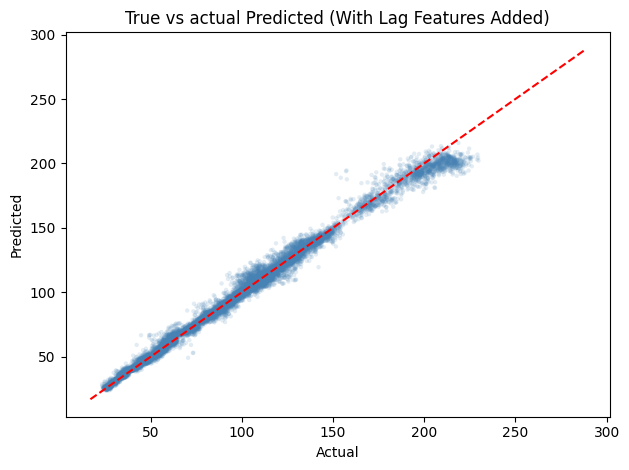

In [205]:
predictions = XGBr.predict(X_test)
plt.scatter(y_test, predictions, alpha=0.15, s=10, color='steelblue', edgecolors='none')

lo = min(y.min(), predictions.min())
hi = max(y.max(), predictions.max())
plt.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5)

plt.title("True vs actual Predicted (With Lag Features Added)")
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()